In [20]:
import numpy as np
from pathlib import Path
import obspy

### 1. Pick the events to consider

In [21]:
e1='E4_a80'
e2='E7_a216'

### 2. Read the synthetic seismograms

Read the E2_a95 synthetic earthquake twice so that it can be used as both the target and reference event.

In [22]:


data_dir = Path("EXAMPLE_SEISMOGRAMS/synthetic_earthquakes")
e1_file = data_dir / f"{e1}.mseed"
e2_file = data_dir / f"{e2}.mseed"

st1 = obspy.read(str(e1_file))
st2 = obspy.read(str(e2_file))

# Just hardcode the start time to 10 seconds for both streams so they are aligned.
for stream in (st1, st2):
    for tr in stream:
        tr.stats.t0 = 10.0

# Use the common duration so every station contributes the same sample range.
min_npts = min(tr.stats.npts for tr in st1 + st2)
for stream in (st1, st2):
    for tr in stream:
        tr.trim(endtime=tr.stats.starttime + (min_npts - 1) / tr.stats.sampling_rate)

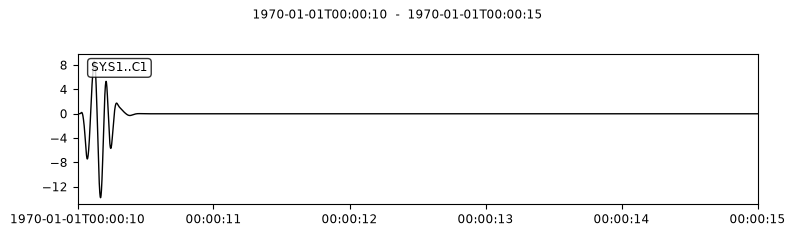

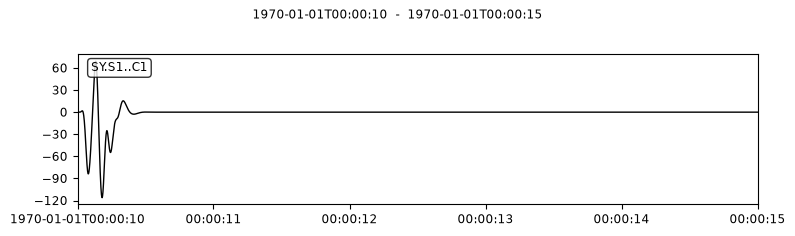

In [23]:
# Have a look at one trace from each copy.
tr1 = st1[0]
t1 = tr1.stats.starttime + tr1.stats.t0
tr1.plot(starttime=t1, endtime=t1 + 5);

tr2 = st2.select(station=tr1.stats.station)[0]
t2 = tr2.stats.starttime + tr2.stats.t0
tr2.plot(starttime=t2, endtime=t2 + 5);

### 2. Read the corresponding synthetic earthquake calculations

In [24]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../SynthEQ").resolve()))
from syntheq2 import read_event

data_dir = Path("EXAMPLE_SEISMOGRAMS/synthetic_earthquakes")
e1_file = data_dir / f"{e1}.h5"
e2_file = data_dir / f"{e2}.h5"
earthquake1 = read_event(e1_file)
earthquake2 = read_event(e2_file)

print("Loaded saved synthetic earthquake:")
print(earthquake1["parameters"])
print("ASTF shape:", earthquake1["apparent_stf"].shape)
print("Seismogram shape:", earthquake1["seismograms"].shape)

Loaded saved synthetic earthquake:
{'a': np.float64(80.48087385839177), 'b': np.float64(80.48087385839177), 'dip': np.float64(90.0), 'event_id': 'E4_a80', 'hypocentre': array([0., 0.]), 'hypocentre_coordinates': 'physical', 'maximum_slip': np.float64(nan), 'metadata_json': '{}', 'rise_time': np.float64(0.06), 'rupture_velocity': np.float64(2800.0), 'seed': np.int64(2611373896), 'seismic_moment': np.float64(3574548938046.703), 'strike': np.float64(0.0)}
ASTF shape: (10, 107)
Seismogram shape: (10, 607)


### 3. Compute the coherence

In [25]:
import matplotlib.pyplot as plt
import phscoh

# Compute the cross-spectra using the t0 picks set above.
xc = phscoh.calcxc(
    st1,
    st2,
    trange=[0.0, 1.8],
    mk1="t0",
    mk2="t0",
    tpr="cosine",
)

print("The cross spectra have shape")
print(xc.xc.shape)

# Calculate moveout and phase coherence.
xc.compute_coherence();

The cross spectra have shape
(720, 10, 1)


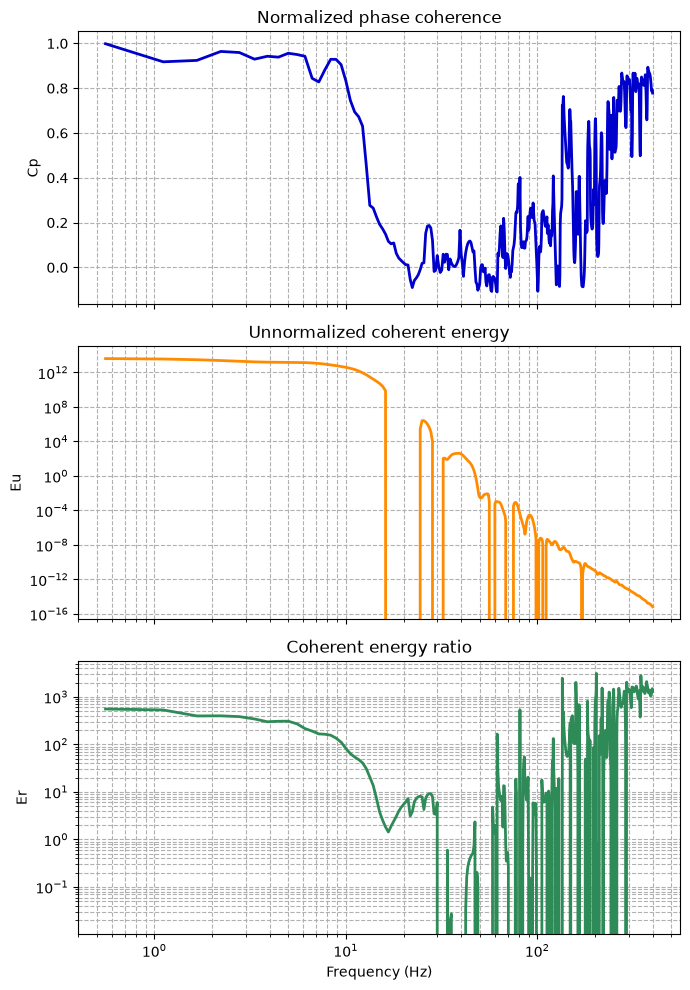

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

axes[0].plot(xc.freq, xc.Cp, linewidth=2.0, color="mediumblue")
axes[0].set_ylabel("Cp")
axes[0].set_title("Normalized phase coherence")

axes[1].plot(xc.freq, xc.Eu, linewidth=2.0, color="darkorange")
axes[1].set_ylabel("Eu")
axes[1].set_title("Unnormalized coherent energy")
axes[1].set_yscale("log")

axes[2].plot(xc.freq, xc.Er, linewidth=2.0, color="seagreen")
axes[2].set_ylabel("Er")
axes[2].set_title("Coherent energy ratio")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_yscale("log")

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, which="both", linestyle="--")

fig.tight_layout()
plt.show()

### 4. Calculate the power in the STFs

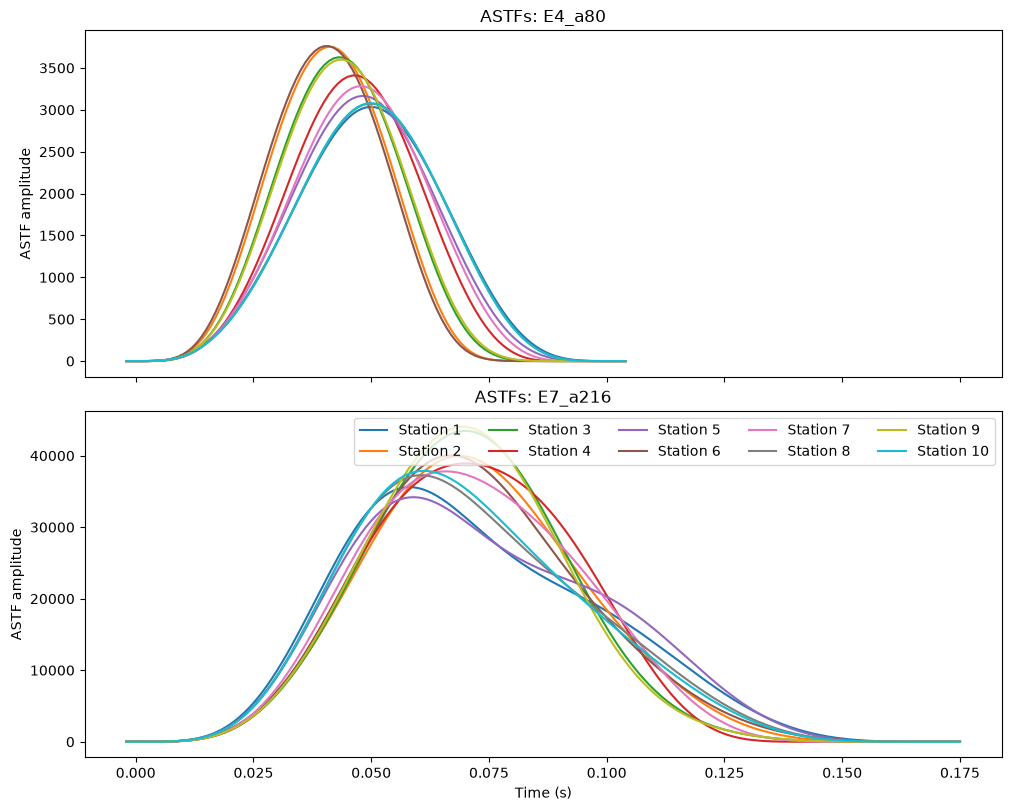

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

for station in range(earthquake1["apparent_stf"].shape[0]):
    axes[0].plot(earthquake1["astf_time"], earthquake1["apparent_stf"][station], label=f"Station {station + 1}")
    axes[1].plot(earthquake2["astf_time"], earthquake2["apparent_stf"][station], label=f"Station {station + 1}")

axes[0].set_title(f"ASTFs: {e1}")
axes[1].set_title(f"ASTFs: {e2}")
axes[0].set_ylabel("ASTF amplitude")
axes[1].set_ylabel("ASTF amplitude")
axes[1].set_xlabel("Time (s)")
axes[1].legend(ncol=5)
plt.show()

In [28]:
# Match the FFT frequency spacing to the coherence calculation.
df_coherence = np.mean(np.diff(xc.freq))
dt_astf = np.mean(np.diff(earthquake1["astf_time"]))
Nft = int(round(1.0 / (df_coherence * dt_astf)))

# initialize
freq_astf = np.fft.rfftfreq(Nft, d=dt_astf)
astf_powers1 = []
astf_powers2 = []

# compute the ASTF power spectra for each station in both earthquakes.
for station in range(earthquake1["apparent_stf"].shape[0]):
    astf_pow = np.fft.rfft(earthquake1["apparent_stf"][station], n=Nft)
    astf_powers1.append(np.abs(astf_pow) ** 2)

    astf_pow = np.fft.rfft(earthquake2["apparent_stf"][station], n=Nft)
    astf_powers2.append(np.abs(astf_pow) ** 2)

astf_powers1 = np.asarray(astf_powers1)
astf_powers2 = np.asarray(astf_powers2)

# and average the ASTF power spectra across stations.
stf_power1 = np.mean(astf_powers1, axis=0)
stf_power2 = np.mean(astf_powers2, axis=0)

print("STF power shape:", stf_power1.shape)

STF power shape: (901,)


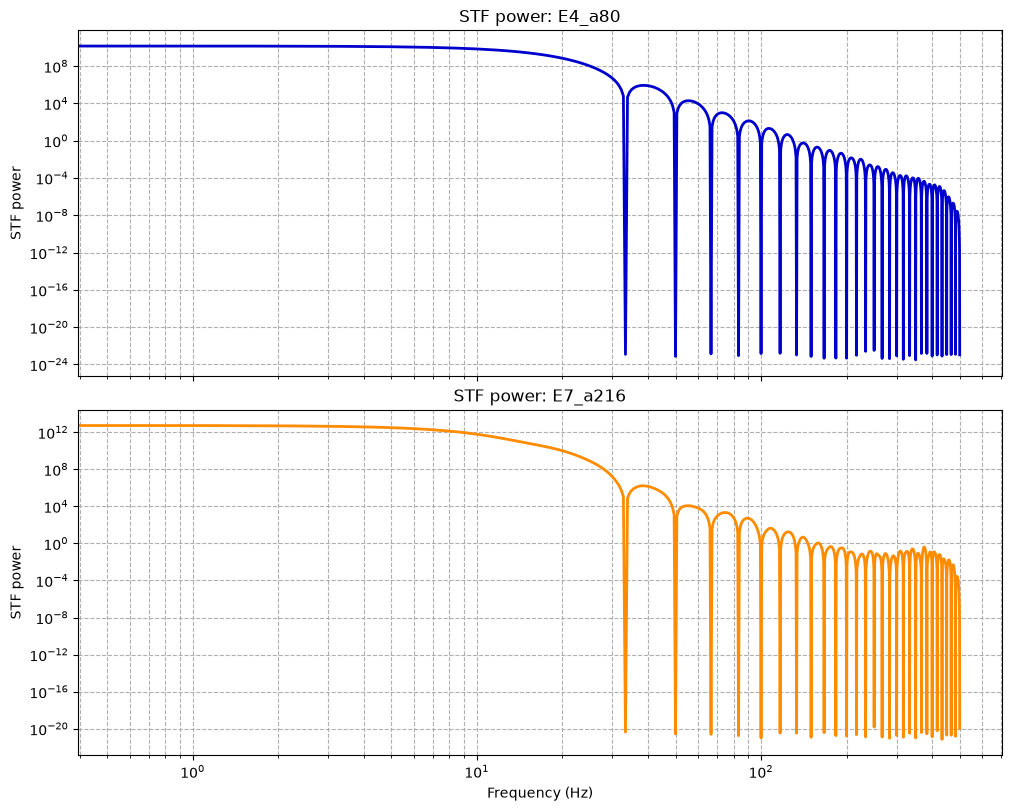

In [29]:
# plot the stf power for the two earthquakes.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
axes[0].plot(freq_astf, stf_power1, linewidth=2.0, color="mediumblue")
axes[0].set_title(f"STF power: {e1}")
axes[0].set_ylabel("STF power")
axes[1].plot(freq_astf, stf_power2, linewidth=2.0, color="darkorange")
axes[1].set_title(f"STF power: {e2}")
axes[1].set_ylabel("STF power")
axes[1].set_xlabel("Frequency (Hz)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--") 

### 5. Compute the power in the GF

In [30]:
import h5py

def read_greens_functions(path):
    with h5py.File(path, "r") as handle:
        time = handle["greens_functions/time"][:]
        values = handle["greens_functions/values"][:]
    return time, values

gf_time1, greens1 = read_greens_functions(e1_file)
gf_time2, greens2 = read_greens_functions(e2_file)
dt_gf = np.mean(np.diff(gf_time1))
Nft_gf = int(round(1.0 / (df_coherence * dt_gf)))
freq_gf = np.fft.rfftfreq(Nft_gf, d=dt_gf)

gf_powers1 = []
gf_powers2 = []
for station in range(greens1.shape[0]):
    gf_pow = np.fft.rfft(greens1[station], n=Nft_gf)
    gf_powers1.append(np.abs(gf_pow) ** 2)

    gf_pow = np.fft.rfft(greens2[station], n=Nft_gf)
    gf_powers2.append(np.abs(gf_pow) ** 2)

gf_powers1 = np.asarray(gf_powers1)
gf_powers2 = np.asarray(gf_powers2)
gf_power1 = np.mean(gf_powers1, axis=0)
gf_power2 = np.mean(gf_powers2, axis=0)

print(f"GF frequency spacing: {np.mean(np.diff(freq_gf)):g} Hz")
print(f"GF time step: {dt_gf:g} s")
print(f"Nft: {Nft_gf}")
print("GF power shape:", gf_power1.shape)

GF frequency spacing: 0.555556 Hz
GF time step: 0.001 s
Nft: 1800
GF power shape: (901,)


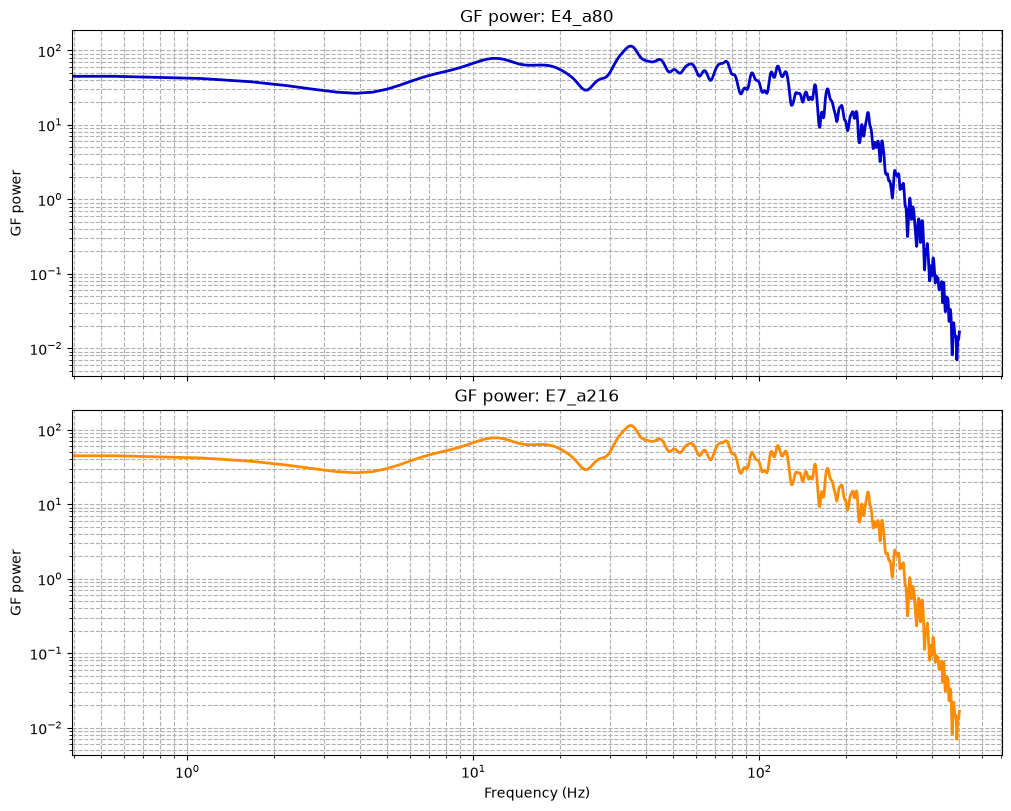

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
axes[0].plot(freq_gf, gf_power1, linewidth=2.0, color="mediumblue")
axes[0].set_title(f"GF power: {e1}")
axes[0].set_ylabel("GF power")
axes[1].plot(freq_gf, gf_power2, linewidth=2.0, color="darkorange")
axes[1].set_title(f"GF power: {e2}")
axes[1].set_ylabel("GF power")
axes[1].set_xlabel("Frequency (Hz)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--")
plt.show()

### 6. Compare computed and "expected" $E_u$

At low frequencies, we expect

$$
E_u^{\mathrm{abs}}
=
|\hat{s}_{1k}|\,|\hat{s}_{2k}|\,
|\hat{s}_{1l}|\,|\hat{s}_{2l}|\,
|\hat g_k|^2|\hat g_l|^2.
$$

or approximately

$$
E_u^{\mathrm{abs}}
=
|\hat{s}_{1}|^2\,|\hat{s}_{2}|^2\,
|\hat g_k|^2|\hat g_l|^2.
$$

In [32]:
# Expected unnormalized coherent energy from station-averaged powers.
assert np.allclose(freq_astf, freq_gf)
freq_exp = freq_astf
Eu_exp = stf_power1 * stf_power2 * gf_power1 * gf_power2

print("Expected Eu shape:", Eu_exp.shape)
print("Expected Eu frequency range:", freq_exp[0], "to", freq_exp[-1], "Hz")

Expected Eu shape: (901,)
Expected Eu frequency range: 0.0 to 500.0 Hz


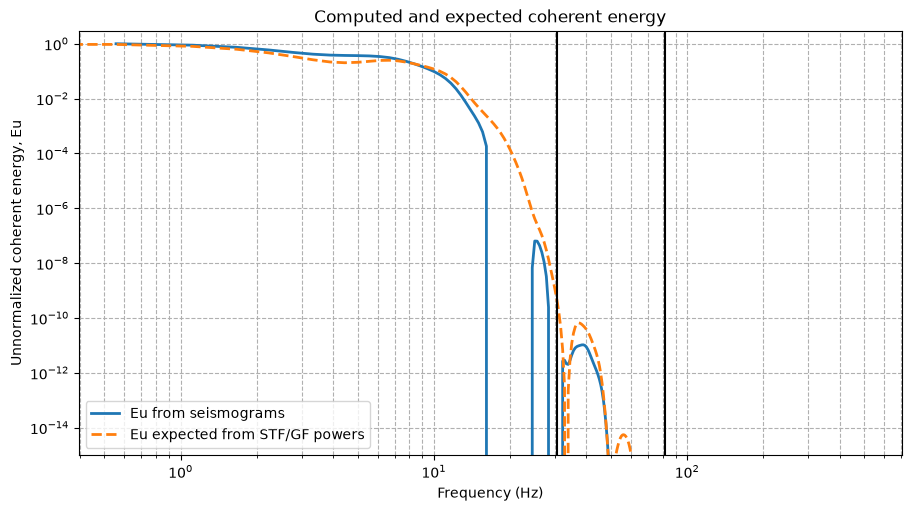

In [38]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

normalize=True
if normalize:
    nml_exp=np.max(Eu_exp)
    nml_xc=np.max(xc.Eu)
else:
    nml_exp=1.0
    nml_xc=1.0

ax.plot(xc.freq, xc.Eu/nml_xc, linewidth=2.0, label="Eu from seismograms")
ax.plot(freq_exp, Eu_exp/nml_exp, linewidth=2.0, linestyle="--", label="Eu expected from STF/GF powers")
a1 = earthquake1["parameters"]["a"]
a2 = earthquake2["parameters"]["a"]
ax.axvline(6000.0 * 1.1 / a1, color="black")
ax.axvline(6000.0 * 1.1 / a2, color="black")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Unnormalized coherent energy, Eu")
ax.set_title("Computed and expected coherent energy")
ax.grid(True, which="both", linestyle="--")
ax.legend()
ymax=np.max([np.max(xc.Eu/nml_xc), np.max(Eu_exp/nml_exp)])
ax.set_ylim([ymax*1e-15, ymax*3])
plt.show()

### 7. Compare computed and "expected" $E_r$

At low frequencies, we expect

$$
E_r^{\mathrm{abs}}
=
\frac{
|\hat s_{2k}|\,|\hat s_{2l}|
}{
|\hat s_{1k}|\,|\hat s_{1l}|
}.
$$

Or approximately

$$
E_r^{\mathrm{abs}}
=
\frac{
|\hat s_{2}|^2
}{
|\hat s_{1}|^2
}.
$$

In [39]:
# Expected absolute energy ratio from station-averaged STF powers.
Er_exp = stf_power2 / stf_power1

print("Expected Er shape:", Er_exp.shape)
print("Expected Er frequency range:", freq_astf[0], "to", freq_astf[-1], "Hz")

Expected Er shape: (901,)
Expected Er frequency range: 0.0 to 500.0 Hz


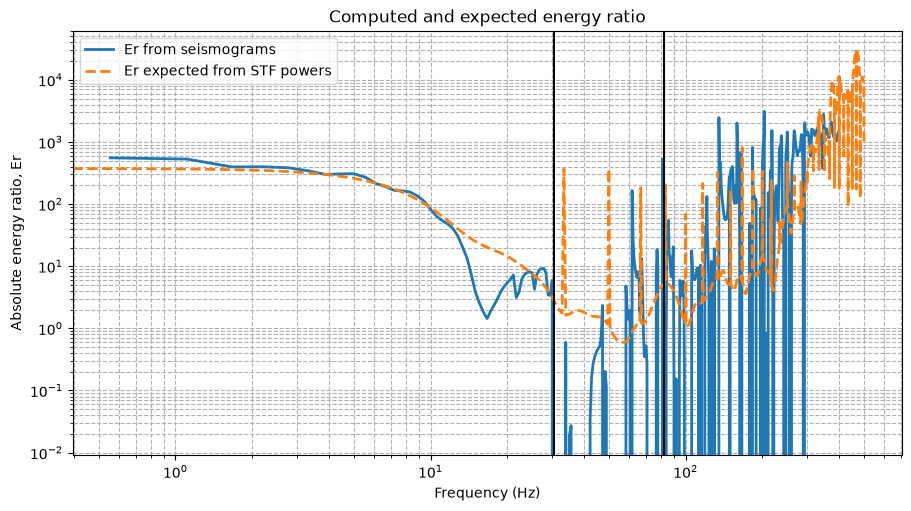

In [40]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(xc.freq, xc.Er, linewidth=2.0, label="Er from seismograms")
ax.plot(freq_astf, Er_exp, linewidth=2.0, linestyle="--", label="Er expected from STF powers")
ax.axvline(6000.0 * 1.1 / a1, color="black")
ax.axvline(6000.0 * 1.1 / a2, color="black")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Absolute energy ratio, Er")
ax.set_title("Computed and expected energy ratio")
ax.grid(True, which="both", linestyle="--")
ax.legend()
plt.show()